In [14]:
import os
import shutil
import gzip
import pandas as pd

# --- 1. SETUP & METADATA LOADING ---
INPUT_DIR = "sigprofiler_input_all_variants"

if os.path.exists(INPUT_DIR):
    shutil.rmtree(INPUT_DIR)
os.makedirs(INPUT_DIR, exist_ok=True)

def is_gzipped(file_path):
    try:
        with open(file_path, 'rb') as f: return f.read(2) == b'\x1f\x8b'
    except Exception: return False

# Update these paths to point to your actual CSV manifests
snv_csv_path = "../../data/snvs/filtered_denominator_v2_20_features/master_list.csv"
indel_csv_path = "../../data/indels/filtered_WES_denominator_v2_indel_20_features/master_list.csv"

# Load metadata and explicitly tag the variant type
df_snv = pd.read_csv(snv_csv_path)
df_snv['variant_type'] = 'SNV'

df_indel = pd.read_csv(indel_csv_path)
df_indel['variant_type'] = 'INDEL'

# Combine and drop duplicates
df_meta = pd.concat([df_snv, df_indel], ignore_index=True)
df_meta = df_meta.drop_duplicates(subset=['sample_id', 'vcf_path', 'variant_type'])

# --- 2. CLEAN & AGGREGATE SAMPLE TYPES ---
# Group 'cord' (case-insensitive) into 'PBMCs'
df_meta['sample_type'] = df_meta['sample_type'].replace(['cord', 'Cord', 'CORD'], 'PBMCs')

# Retain your logic for LEGACY/UKCTOCS
mask_pbmc = df_meta['sample_id'].str.startswith('UKCTOCS') | df_meta['sample_id'].str.startswith('LEGACY')
df_meta.loc[mask_pbmc, 'sample_type'] = 'PBMCs'

# Save a clean mapping file
mapping_df = df_meta[['sample_id', 'sample_type']].drop_duplicates()
mapping_df.to_csv("sample_type_mapping.csv", index=False)
print("✅ Saved metadata mapping to 'sample_type_mapping.csv'")

# --- 3. AGGREGATE VCFS ---
processed_files = set()

for _, row in df_meta.iterrows():
    vcf_path = row['vcf_path']
    sample_id = row['sample_id']
    variant_type = row['variant_type']
    
    if not isinstance(vcf_path, str) or not os.path.exists(vcf_path):
        print(f"⚠️ [WARN] VCF not found for {sample_id} ({variant_type}): {vcf_path}")
        continue
        
    # Name the file with the variant type so SNVs and INDELs don't overwrite/skip each other
    out_name = f"{sample_id}_{variant_type}.vcf"
    out_path = os.path.join(INPUT_DIR, out_name)
    
    # Check against the specific output filename, not just the sample_id
    if out_name in processed_files:
        continue
        
    try:
        if is_gzipped(vcf_path):
            with gzip.open(vcf_path, 'rb') as f_in:
                with open(out_path, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
        else:
            shutil.copy(vcf_path, out_path)
            
        processed_files.add(out_name)
    except Exception as e:
        print(f"❌ [ERROR] Failed to copy {vcf_path}: {e}")

print(f"🎯 Prepared {len(processed_files)} unzipped, renamed VCFs in {INPUT_DIR} for SigProfiler.")

✅ Saved metadata mapping to 'sample_type_mapping.csv'
🎯 Prepared 72 unzipped, renamed VCFs in sigprofiler_input_all_variants for SigProfiler.


In [15]:
# --- 2. GENERATE THE MATRICES ---
from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen

print("\nGenerating Mutational Matrices (SBS96, DBS78, ID83)...")

matrices = matGen.SigProfilerMatrixGeneratorFunc(
    "Combined_Cohort",    # Project name
    "GRCh38",             # Reference genome
    INPUT_DIR,            # Input directory containing unzipped VCFs
    plot=True,            
    exome=True,           # SET TO TRUE for WES data (crucial for SBS normalization)
    bed_file=None,
    chrom_based=False,
    tsb_stat=False,
    seqInfo=False,
    cushion=100
)
print("Matrices successfully generated!")


Generating Mutational Matrices (SBS96, DBS78, ID83)...
Starting matrix generation for SNVs and DINUCs...Completed! Elapsed time: 111.55 seconds.
Starting matrix generation for INDELs...Completed! Elapsed time: 24.97 seconds.
Matrices generated for 72 samples with 60 errors. Total of 29984 SNVs, 172 DINUCs, and 1359 INDELs were successfully analyzed.
Matrices successfully generated!


In [16]:
# --- 3. RUN DECONVOLUTION (EXTRACTION) ---
from SigProfilerExtractor import sigpro as sig
import os
import glob

INPUT_DIR = "sigprofiler_input_all_variants"
matrix_base = os.path.join(INPUT_DIR, "output")

# Helper function to dynamically find the matrices
def find_matrix(mut_type, context):
    # Check for .exome (WES), .all (WGS), and .txt fallbacks
    for ext in ["exome", "all", "txt"]:
        search_pattern = os.path.join(matrix_base, mut_type, f"*.{context}.{ext}")
        files = glob.glob(search_pattern)
        if files:
            return files[0]
            
    raise FileNotFoundError(f"Could not find {context} matrix in {os.path.join(matrix_base, mut_type)}")

try:
    sbs96_matrix = find_matrix("SBS", "SBS96")
    dbs78_matrix = find_matrix("DBS", "DBS78")
    id83_matrix  = find_matrix("ID", "ID83")
    
    print(f"✅ Found SBS matrix: {sbs96_matrix}")
    print(f"✅ Found DBS matrix: {dbs78_matrix}")
    print(f"✅ Found ID matrix: {id83_matrix}")
    
except FileNotFoundError as e:
    print(f"❌ {e}")
    raise # Stop execution

# Parameters for Deconvolution
extraction_params = {
    "reference_genome": "GRCh38",
    "minimum_signatures": 1,
    "maximum_signatures": 5,   # Adjust based on cohort size
    "nmf_replicates": 10,      # Increase to 100 for final publication run
    "min_nmf_iterations": 10000,
    "max_nmf_iterations": 1000000,
    "nmf_test_conv": 1000,
    "nmf_tolerance": 1e-15,
    "make_decomposition_plots": True,
    "exome": True              # Ensure extractor knows it is WES
}

print("\nExtracting SBS Signatures...")
sig.sigProfilerExtractor("matrix", "sigprofiler_output_SBS", sbs96_matrix, **extraction_params)

print("\nExtracting DBS Signatures...")
sig.sigProfilerExtractor("matrix", "sigprofiler_output_DBS", dbs78_matrix, **extraction_params)

print("\nExtracting ID Signatures...")
sig.sigProfilerExtractor("matrix", "sigprofiler_output_ID", id83_matrix, **extraction_params)

print("\nDeconvolution complete for all mutation types.")

✅ Found SBS matrix: sigprofiler_input_all_variants/output/SBS/Combined_Cohort.SBS96.exome
✅ Found DBS matrix: sigprofiler_input_all_variants/output/DBS/Combined_Cohort.DBS78.exome
✅ Found ID matrix: sigprofiler_input_all_variants/output/ID/Combined_Cohort.ID83.exome

Extracting SBS Signatures...

************** Reported Current Memory Use: 1.28 GB *****************

Extracting signature 1 for mutation type 96
The matrix normalizing cutoff is 9600


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    3.0s remaining:    3.4s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    3.1s remaining:    1.3s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    3.1s remaining:    0.3s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    3.2s finished



 Decomposing De Novo Signatures  .....
Generating plots for COSMIC_v3.5_SBS_GRCh37_exome now...
Plots for COSMIC_v3.5_SBS_GRCh37_exome have been successfully installed.
Decompositon Plot:SBS96A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (7855.95/s) 
Decompositon Plot:SBS96B |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (17009.11/s) 

 Assigning decomposed signature


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    0.1s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 

Extracting DBS Signatures...

************** Reported Current Memory Use: 3.27 GB *****************

Extracting signature 1 for mutation type DINUC
The matrix normalizing cutoff is 7800


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

Time taken to collect 10 iterations for 1 signatures is 5.73 seconds
Optimization time 

...



 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 

Extracting ID Signatures...

************** Reported Current Memory Use: 1.5 GB *****************

Extracting signature 1 for mutation type INDEL
The matrix normalizing cutoff is 8300


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

Time taken to collect 10 iterations for 1 signatures is 5.74 seconds
Optimization time is

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    0.1s finished



 Decomposing De Novo Signatures  .....
Decompositon Plot:ID83A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (18348.62/s) 
Decompositon Plot:ID83B |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (17725.15/s) 

 Assigning decomposed signature


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  17 out of  36 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=14)]: Done  25 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  33 out of  36 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  36 out of  36 | elapsed:    0.1s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 

Deconvolution complete for all mutation types.


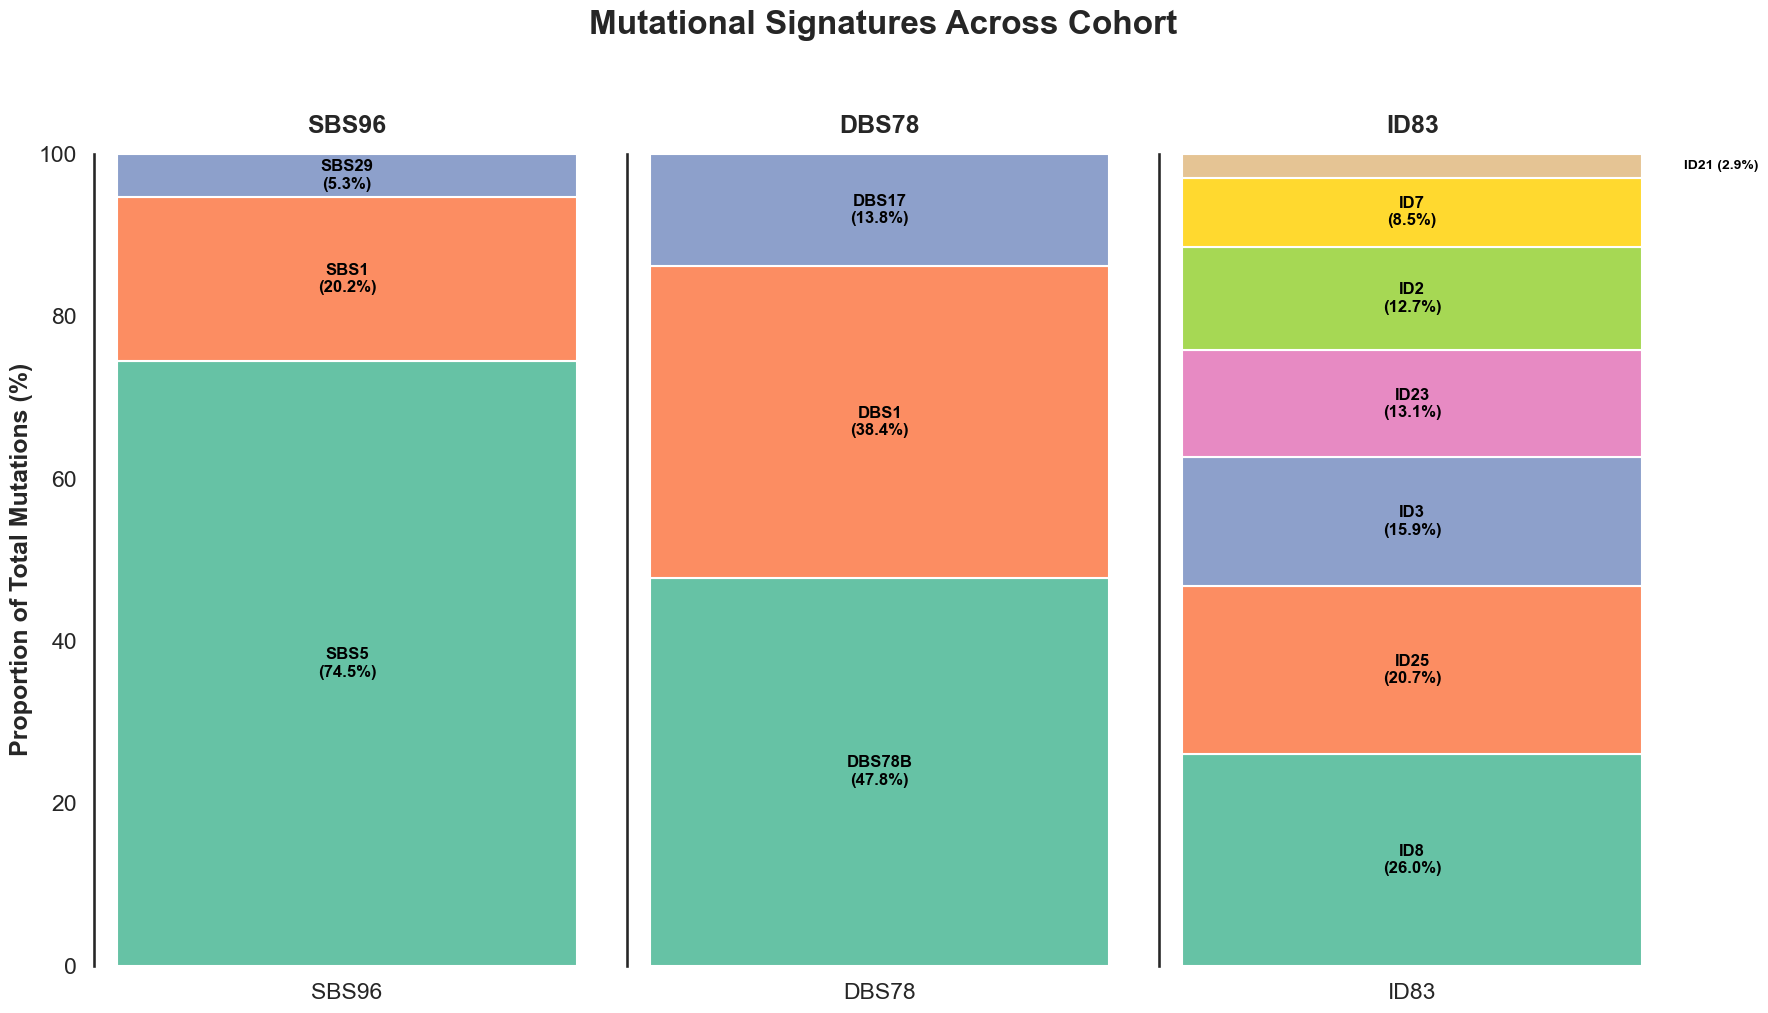

In [17]:
# --- 4. DISPLAY THE PLOTS ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style="white", context="talk")

# Paths to the activities files generated in Step 3
activity_files = {
    "SBS96": "sigprofiler_output_SBS/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Activities/COSMIC_SBS96_Activities_refit.txt",
    "DBS78": "sigprofiler_output_DBS/DBS78/Suggested_Solution/COSMIC_DBS78_Decomposed_Solution/Activities/COSMIC_DBS78_Activities_refit.txt",
    "ID83": "sigprofiler_output_ID/ID83/Suggested_Solution/COSMIC_ID83_Decomposed_Solution/Activities/COSMIC_ID83_Activities_refit.txt"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Mutational Signatures Across Cohort", fontsize=24, weight='bold', y=1.02)

for ax, (mut_type, path_refit) in zip(axes, activity_files.items()):
    # Fallback to non-refit if refit is missing
    path_standard = path_refit.replace("_refit.txt", ".txt")
    target_path = path_refit if os.path.exists(path_refit) else path_standard
    
    if not os.path.exists(target_path):
        ax.text(0.5, 0.5, f"Data Not Found\n{mut_type}", ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
        continue

    # Load and clean data
    df_act = pd.read_csv(target_path, sep="\t")
    if 'Samples' in df_act.columns:
        df_act.set_index("Samples", inplace=True)
    elif len(df_act.columns) > 0 and df_act.columns[0] == 'Unnamed: 0':
        df_act.rename(columns={'Unnamed: 0': 'Samples'}, inplace=True)
        df_act.set_index("Samples", inplace=True)
        
    total_counts = df_act.sum(axis=0, numeric_only=True)
    total_counts = total_counts[total_counts > 0].sort_values(ascending=False)
    
    if total_counts.empty:
        ax.text(0.5, 0.5, f"No counts for {mut_type}", ha='center', va='center')
        continue

    proportions = total_counts / total_counts.sum() * 100
    colors = sns.color_palette("Set2", len(proportions))
    
    bottom = 0
    for i, (sig, pct) in enumerate(proportions.items()):
        ax.bar(f"{mut_type}", pct, bottom=bottom, color=colors[i], edgecolor='white', width=0.6)
        
        # Label placement logic
        if pct >= 5.0:
            ax.text(0, bottom + (pct / 2), f"{sig}\n({pct:.1f}%)", 
                    ha='center', va='center', color='black', weight='bold', fontsize=12)
        else:
            ax.text(0.35, bottom + (pct / 2), f" {sig} ({pct:.1f}%)", 
                    ha='left', va='center', color='black', weight='bold', fontsize=10)
        
        bottom += pct
        
    ax.set_ylim(0, 100)
    ax.set_title(f"{mut_type}", fontsize=18, pad=15, weight='bold')
    
    if mut_type == "SBS96":
        ax.set_ylabel("Proportion of Total Mutations (%)", weight='bold')
        
    sns.despine(ax=ax, bottom=True)
    ax.tick_params(bottom=False)

plt.tight_layout()
plt.show()

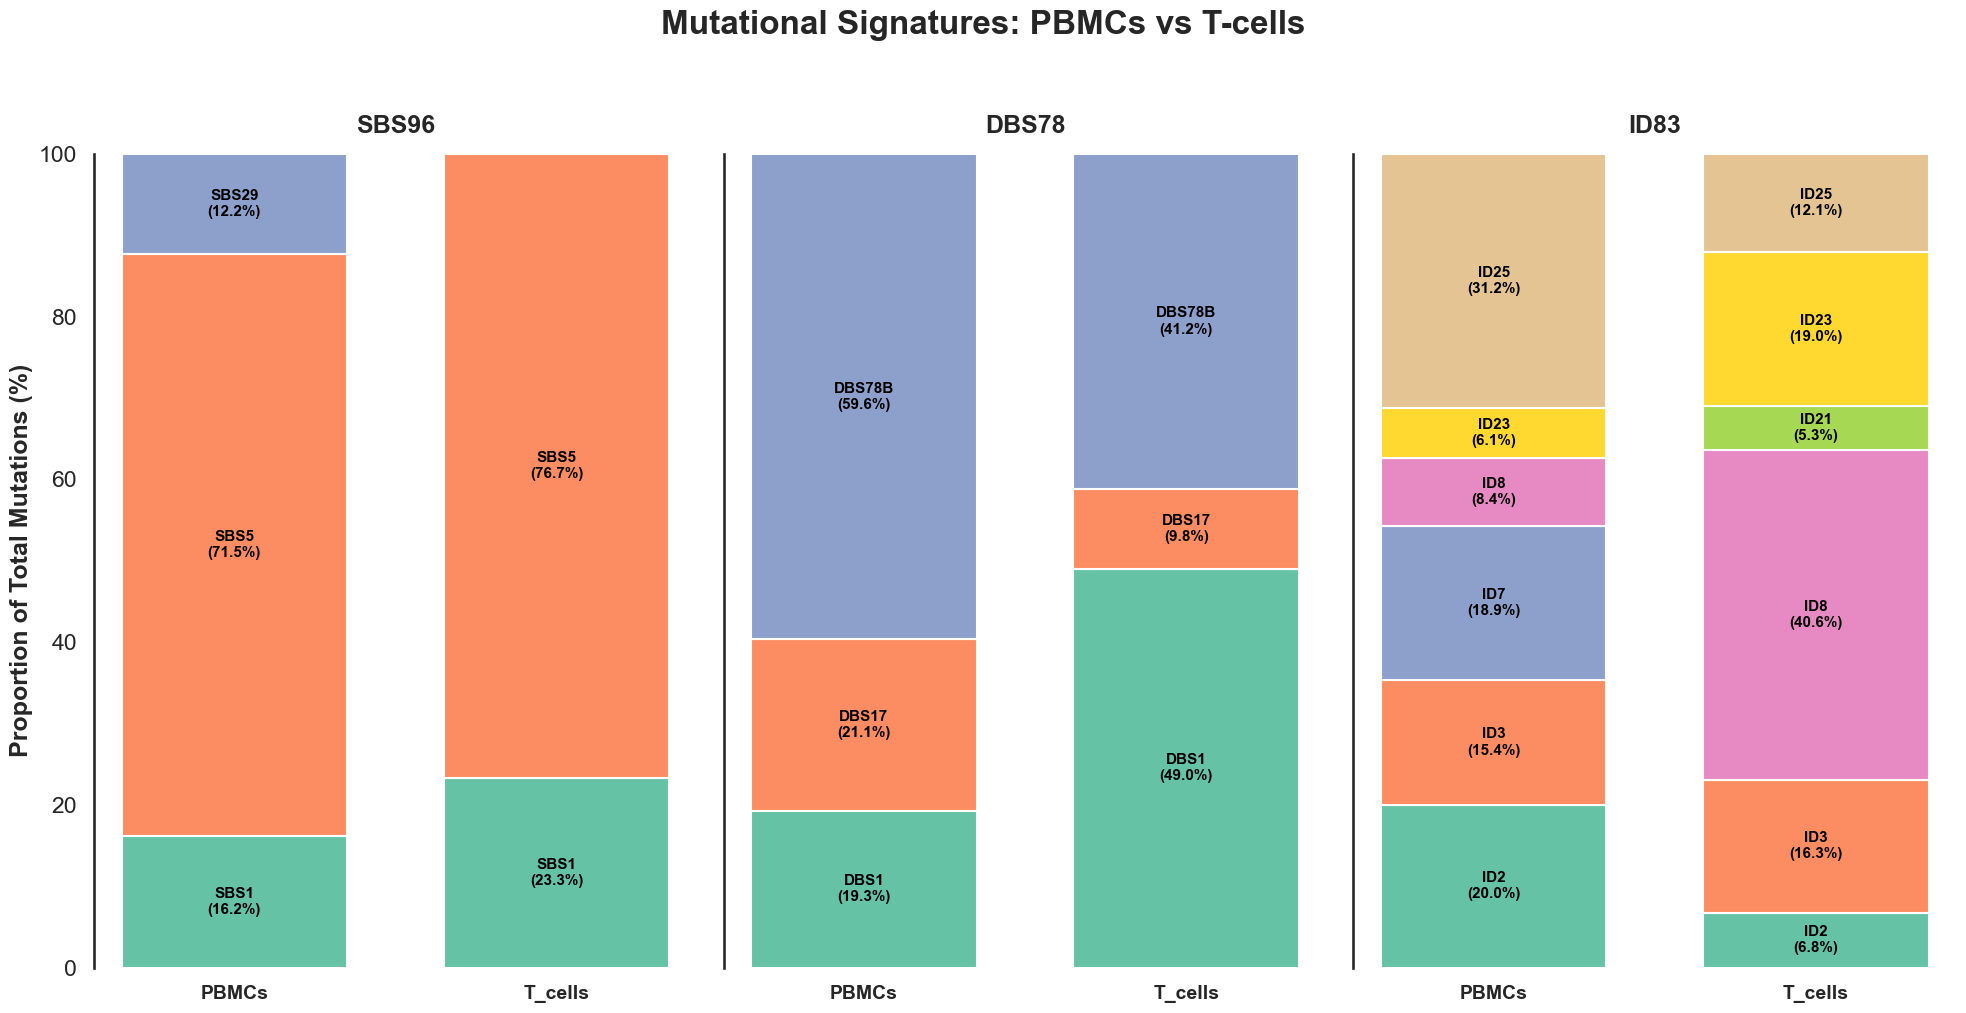

In [18]:
# --- 4. DISPLAY THE PLOTS (BY SAMPLE TYPE) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style="white", context="talk")

# Load the mapping file created in Step 1
mapping_df = pd.read_csv("sample_type_mapping.csv")

# Paths to the activities files generated in Step 3
activity_files = {
    "SBS96": "sigprofiler_output_SBS/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Activities/COSMIC_SBS96_Activities_refit.txt",
    "DBS78": "sigprofiler_output_DBS/DBS78/Suggested_Solution/COSMIC_DBS78_Decomposed_Solution/Activities/COSMIC_DBS78_Activities_refit.txt",
    "ID83": "sigprofiler_output_ID/ID83/Suggested_Solution/COSMIC_ID83_Decomposed_Solution/Activities/COSMIC_ID83_Activities_refit.txt"
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
fig.suptitle("Mutational Signatures: PBMCs vs T-cells", fontsize=24, weight='bold', y=1.02)

for ax, (mut_type, path_refit) in zip(axes, activity_files.items()):
    # Fallback to non-refit if refit is missing
    path_standard = path_refit.replace("_refit.txt", ".txt")
    target_path = path_refit if os.path.exists(path_refit) else path_standard
    
    if not os.path.exists(target_path):
        ax.text(0.5, 0.5, f"Data Not Found\n{mut_type}", ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
        continue

    # Load data
    df_act = pd.read_csv(target_path, sep="\t")
    if 'Samples' in df_act.columns:
        df_act.set_index("Samples", inplace=True)
    elif len(df_act.columns) > 0 and df_act.columns[0] == 'Unnamed: 0':
        df_act.rename(columns={'Unnamed: 0': 'Samples'}, inplace=True)
        df_act.set_index("Samples", inplace=True)
        
    # CRITICAL: Strip the _SNV and _INDEL tags so the index matches the mapping_df sample_ids
    df_act.index = df_act.index.str.replace('_SNV', '', regex=False).str.replace('_INDEL', '', regex=False)
    
    # Merge activity data with the sample type mapping
    df_merged = df_act.reset_index().merge(mapping_df, left_on='Samples', right_on='sample_id', how='inner')
    
    # Extract just the numeric signature columns to sum them up
    sig_cols = df_act.select_dtypes(include='number').columns
    
    # Group by cell type and sum the signature counts
    df_grouped = df_merged.groupby('sample_type')[sig_cols].sum()
    
    # Drop signatures that have 0 counts across both cell types to keep colors clean
    df_grouped = df_grouped.loc[:, (df_grouped != 0).any(axis=0)]
    
    if df_grouped.empty:
        ax.text(0.5, 0.5, f"No counts for {mut_type}", ha='center', va='center')
        continue

    # Convert raw counts to proportions (percentages) per cell type
    df_prop = df_grouped.div(df_grouped.sum(axis=1), axis=0) * 100
    
    # Setup for plotting
    sample_types = df_prop.index.tolist()
    x_positions = range(len(sample_types))
    colors = sns.color_palette("Set2", len(df_grouped.columns))
    
    # Track the bottom of the stacked bars
    bottoms = [0] * len(sample_types)
    
    for i, sig in enumerate(df_grouped.columns):
        pcts = df_prop[sig].fillna(0).tolist()
        
        ax.bar(x_positions, pcts, bottom=bottoms, color=colors[i], edgecolor='white', width=0.7)
        
        # Label placement logic inside the bars
        for j, pct in enumerate(pcts):
            if pct >= 5.0:
                ax.text(x_positions[j], bottoms[j] + (pct / 2), f"{sig}\n({pct:.1f}%)", 
                        ha='center', va='center', color='black', weight='bold', fontsize=11)
        
        # Update bottoms for the next signature in the stack
        bottoms = [b + p for b, p in zip(bottoms, pcts)]
        
    # Aesthetics
    ax.set_xticks(x_positions)
    ax.set_xticklabels(sample_types, weight='bold', fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_title(f"{mut_type}", fontsize=18, pad=15, weight='bold')
    
    if mut_type == "SBS96":
        ax.set_ylabel("Proportion of Total Mutations (%)", weight='bold')
        
    sns.despine(ax=ax, bottom=True)
    ax.tick_params(bottom=False)

plt.tight_layout()
plt.show()

In [19]:
import os
import shutil
import pandas as pd

SOURCE_DIR = "sigprofiler_input_all_variants"
mapping_df = pd.read_csv("sample_type_mapping.csv")

# Identify unique cell types (e.g., 'PBMCs', 'T_cells')
cell_types = mapping_df['sample_type'].dropna().unique()

print("Splitting VCFs by sample type...")

# Create dedicated input directories for each cell type
for ct in cell_types:
    dir_name = f"input_{ct}"
    if os.path.exists(dir_name):
        shutil.rmtree(dir_name) # Clean start
    os.makedirs(dir_name, exist_ok=True)

# Copy files to their respective directories
copied_counts = {ct: 0 for ct in cell_types}

for _, row in mapping_df.iterrows():
    sample_id = row['sample_id']
    cell_type = row['sample_type']
    target_dir = f"input_{cell_type}"
    
    # Find both _SNV and _INDEL files for this sample
    for f in os.listdir(SOURCE_DIR):
        if f.startswith(f"{sample_id}_") and f.endswith(".vcf"):
            src = os.path.join(SOURCE_DIR, f)
            dst = os.path.join(target_dir, f)
            shutil.copy(src, dst)
            copied_counts[cell_type] += 1

for ct, count in copied_counts.items():
    print(f"✅ Copied {count} VCFs into input_{ct}/")

Splitting VCFs by sample type...
✅ Copied 20 VCFs into input_T_cells/
✅ Copied 52 VCFs into input_PBMCs/


In [20]:
from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen
from SigProfilerExtractor import sigpro as sig
import os
import glob
import pandas as pd

# Get the cell types dynamically again
mapping_df = pd.read_csv("sample_type_mapping.csv")
cell_types = mapping_df['sample_type'].dropna().unique()

# Parameters for Deconvolution
extraction_params = {
    "reference_genome": "GRCh38",
    "minimum_signatures": 1,
    "maximum_signatures": 5,   
    "nmf_replicates": 10,      # Increase to 100 later if desired
    "min_nmf_iterations": 10000,
    "max_nmf_iterations": 1000000,
    "nmf_test_conv": 1000,
    "nmf_tolerance": 1e-15,
    "make_decomposition_plots": True,
    "exome": True              
}

for ct in cell_types:
    print(f"\n{'='*50}")
    print(f"🚀 STARTING PIPELINE FOR: {ct}")
    print(f"{'='*50}")
    
    input_dir = f"input_{ct}"
    project_name = f"Cohort_{ct}"
    
    # 1. Generate Matrices
    print(f"\n[1/2] Generating Matrices for {ct}...")
    matGen.SigProfilerMatrixGeneratorFunc(
        project_name, "GRCh38", input_dir, plot=False, exome=True, 
        bed_file=None, chrom_based=False, tsb_stat=False, seqInfo=False, cushion=100
    )
    
    # Helper to find matrices
    matrix_base = os.path.join(input_dir, "output")
    def find_matrix(mut_type, context):
        for ext in ["exome", "all", "txt"]:
            search = glob.glob(os.path.join(matrix_base, mut_type, f"*.{context}.{ext}"))
            if search: return search[0]
        return None

    sbs_matrix = find_matrix("SBS", "SBS96")
    dbs_matrix = find_matrix("DBS", "DBS78")
    id_matrix  = find_matrix("ID", "ID83")
    
    # 2. Deconvolution
    print(f"\n[2/2] Running Deconvolution for {ct}...")
    
    if sbs_matrix:
        print(f"  -> Extracting SBS...")
        sig.sigProfilerExtractor("matrix", f"output_{ct}_SBS", sbs_matrix, **extraction_params)
        
    if dbs_matrix:
        print(f"  -> Extracting DBS...")
        sig.sigProfilerExtractor("matrix", f"output_{ct}_DBS", dbs_matrix, **extraction_params)
        
    if id_matrix:
        print(f"  -> Extracting ID...")
        sig.sigProfilerExtractor("matrix", f"output_{ct}_ID", id_matrix, **extraction_params)

print("\n🎉 Independent extraction complete for all cell types!")


🚀 STARTING PIPELINE FOR: T_cells

[1/2] Generating Matrices for T_cells...
Starting matrix generation for SNVs and DINUCs...Completed! Elapsed time: 1.57 seconds.
Starting matrix generation for INDELs...Completed! Elapsed time: 0.95 seconds.
Matrices generated for 20 samples with 31 errors. Total of 16788 SNVs, 112 DINUCs, and 732 INDELs were successfully analyzed.

[2/2] Running Deconvolution for T_cells...
  -> Extracting SBS...

************** Reported Current Memory Use: 0.65 GB *****************

Extracting signature 1 for mutation type 96
The matrix normalizing cutoff is 9600


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues plea

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:    2.1s remaining:    4.9s
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:    2.1s remaining:    1.4s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    2.2s finished



 Decomposing De Novo Signatures  .....
Decompositon Plot:SBS96A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (21089.93/s) 

 Assigning decomposed signature


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 
  -> Extracting DBS...

************** Reported Current Memory Use: 0.94 GB *****************

Extracting signature 1 for mutation type DINUC
The matrix normalizing cutoff is 7800


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

Time taken to collect 10 iterations for 1 signatures is 4.83 seconds
Optimization time is 2.04

...



 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 
  -> Extracting ID...

************** Reported Current Memory Use: 0.62 GB *****************

Extracting signature 1 for mutation type INDEL
The matrix normalizing cutoff is 8300


process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

process 1 continues please wait... process 1 continues please wait... 

execution time: 1 seconds 

execution time: 1 seconds 

process 1 continues please wait... 
execution time: 1 seconds 

Time taken to collect 10 iterations for 1 signatures is 5.83 seconds
Optimization time is 3.026

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   5 out of  26 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=14)]: Done  11 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  17 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  23 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  26 out of  26 | elapsed:    0.1s finished



 Decomposing De Novo Signatures  .....
Decompositon Plot:ID83A |▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉▉| 1/1 [100%] in 0.0s (13848.69/s) 

 Assigning decomposed signature


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   5 out of  26 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=14)]: Done  11 out of  26 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=14)]: Done  17 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  23 out of  26 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=14)]: Done  26 out of  26 | elapsed:    1.5s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerExtractor.
 

🎉 Independent extraction complete for all cell types!


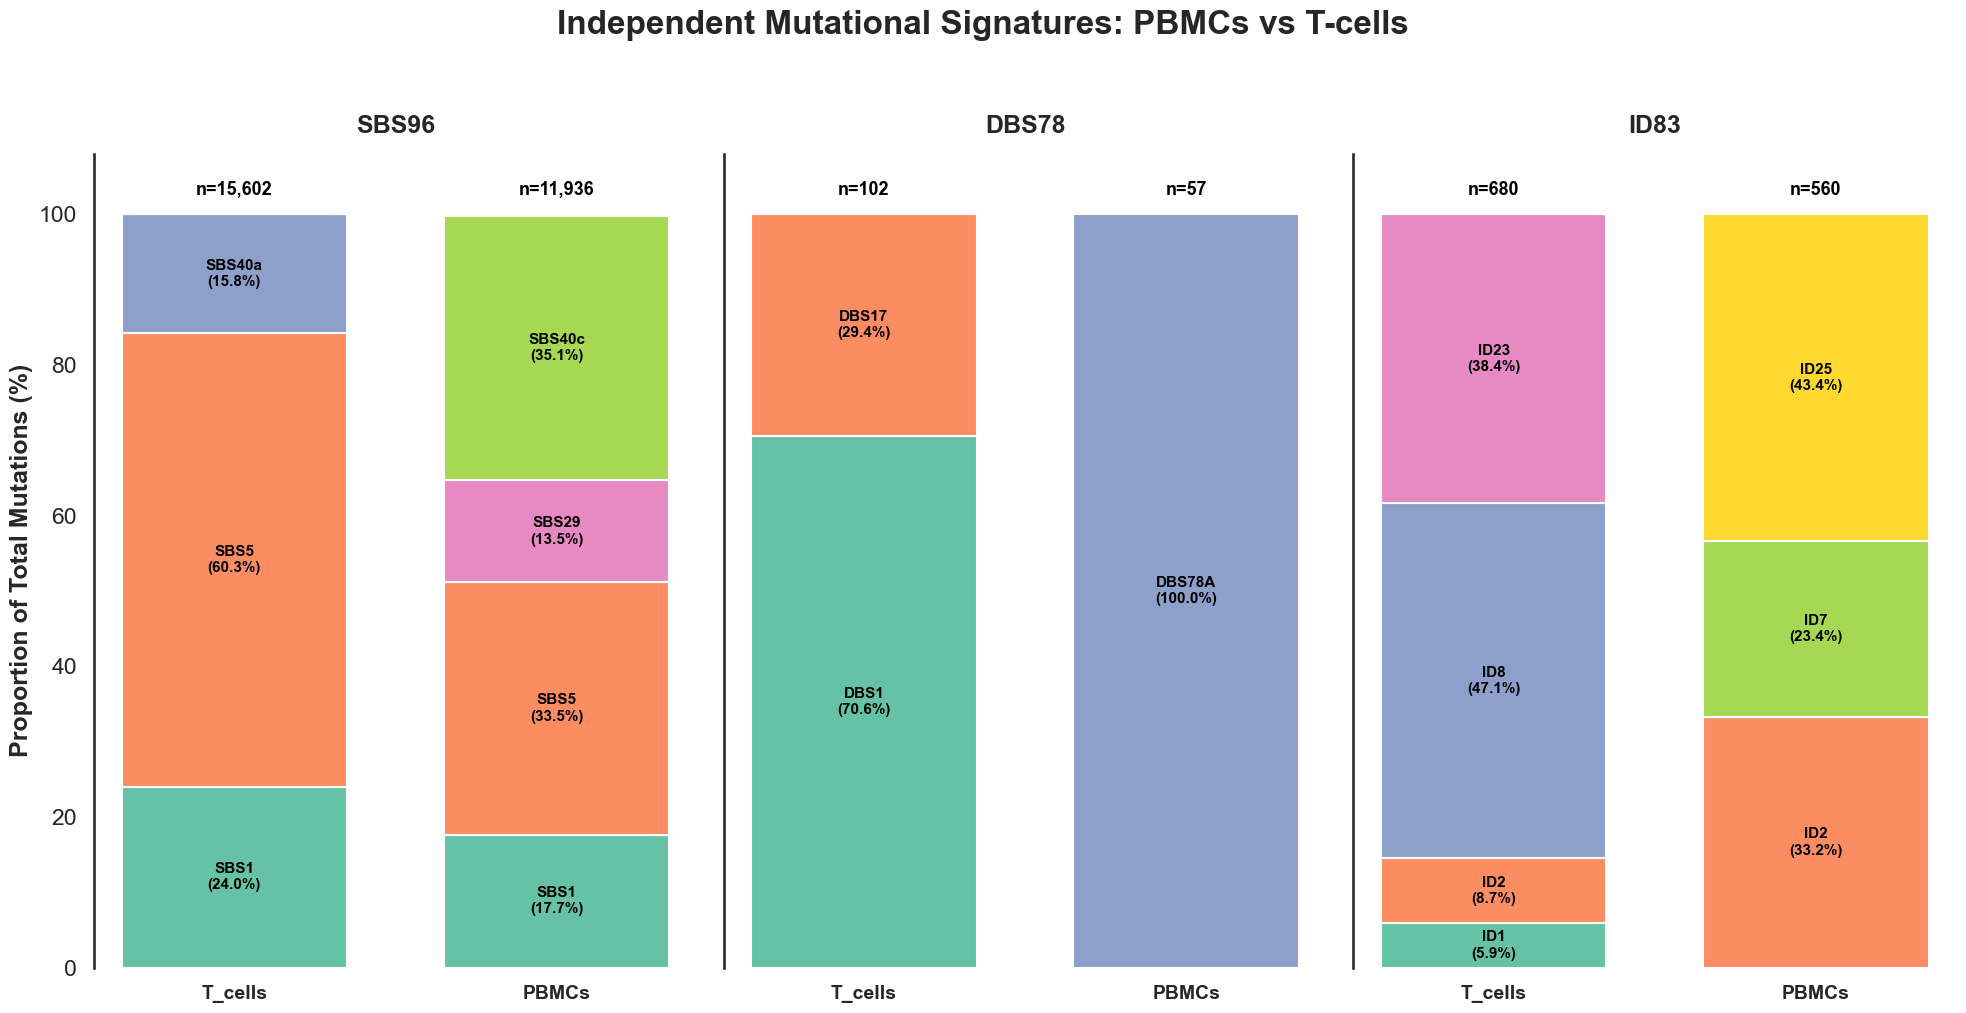

In [22]:
# --- 4. DISPLAY THE PLOTS (INDEPENDENT EXTRACTIONS) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style="white", context="talk")

# Determine cell types dynamically from your mapping file (or hardcode as ["PBMCs", "T_cells"])
mapping_df = pd.read_csv("sample_type_mapping.csv")
cell_types = mapping_df['sample_type'].dropna().unique()

# Map the context (e.g., SBS96) to the broad mutational class used in our folder names (e.g., SBS)
mut_contexts = {
    "SBS96": "SBS",
    "DBS78": "DBS",
    "ID83": "ID"
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
fig.suptitle("Independent Mutational Signatures: PBMCs vs T-cells", fontsize=24, weight='bold', y=1.02)

for ax, (context, mut_class) in zip(axes, mut_contexts.items()):
    
    combined_counts = []
    
    # Loop through each independent cell type extraction
    for ct in cell_types:
        path_refit = f"output_{ct}_{mut_class}/{context}/Suggested_Solution/COSMIC_{context}_Decomposed_Solution/Activities/COSMIC_{context}_Activities_refit.txt"
        path_standard = path_refit.replace("_refit.txt", ".txt")
        
        target_path = path_refit if os.path.exists(path_refit) else path_standard
        
        if os.path.exists(target_path):
            df_act = pd.read_csv(target_path, sep="\t")
            
            # Clean up index
            if 'Samples' in df_act.columns:
                df_act.set_index("Samples", inplace=True)
            elif len(df_act.columns) > 0 and df_act.columns[0] == 'Unnamed: 0':
                df_act.rename(columns={'Unnamed: 0': 'Samples'}, inplace=True)
                df_act.set_index("Samples", inplace=True)
            
            # Sum the activities for this entire cell type
            ct_sums = df_act.select_dtypes(include='number').sum(axis=0)
            ct_sums.name = ct
            combined_counts.append(ct_sums)
        else:
            # If a specific cell type didn't have enough mutations for this context, append empty data
            print(f"⚠️ Notice: Could not find {context} data for {ct}")
            combined_counts.append(pd.Series(name=ct, dtype=float))
            
    # Combine the independent extractions into one DataFrame
    df_grouped = pd.DataFrame(combined_counts).fillna(0)
    
    # Drop signatures that have 0 counts across ALL cell types
    if not df_grouped.empty:
        df_grouped = df_grouped.loc[:, (df_grouped != 0).any(axis=0)]
    
    if df_grouped.empty or df_grouped.sum().sum() == 0:
        ax.text(0.5, 0.5, f"No counts for {context}", ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
        continue

    # Get the raw totals for each cell type before converting to percentages
    total_counts = df_grouped.sum(axis=1)

    # Convert raw counts to proportions (percentages) per cell type
    df_prop = df_grouped.div(total_counts, axis=0) * 100
    
    # Setup for plotting
    plot_labels = df_prop.index.tolist()
    x_positions = range(len(plot_labels))
    colors = sns.color_palette("Set2", len(df_grouped.columns))
    
    # Track the bottom of the stacked bars
    bottoms = [0] * len(plot_labels)
    
    for i, sig in enumerate(df_grouped.columns):
        pcts = df_prop[sig].fillna(0).tolist()
        
        ax.bar(x_positions, pcts, bottom=bottoms, color=colors[i], edgecolor='white', width=0.7)
        
        # Label placement logic inside the bars
        for j, pct in enumerate(pcts):
            if pct >= 5.0:
                ax.text(x_positions[j], bottoms[j] + (pct / 2), f"{sig}\n({pct:.1f}%)", 
                        ha='center', va='center', color='black', weight='bold', fontsize=11)
        
        # Update bottoms for the next signature in the stack
        bottoms = [b + p for b, p in zip(bottoms, pcts)]
        
    # --- NEW: Add total mutation counts above the bars ---
    for j, total in enumerate(total_counts):
        # Format to 0 decimal places with a comma separator for thousands
        ax.text(x_positions[j], 102, f"n={total:,.0f}", 
                ha='center', va='bottom', color='black', weight='bold', fontsize=13)
        
    # Aesthetics
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_labels, weight='bold', fontsize=14)
    # Increased upper y-limit to 108 to make room for the 'n=' labels
    ax.set_ylim(0, 108) 
    ax.set_title(f"{context}", fontsize=18, pad=15, weight='bold')
    
    if context == "SBS96":
        ax.set_ylabel("Proportion of Total Mutations (%)", weight='bold')
        
    sns.despine(ax=ax, bottom=True, left=False)
    ax.tick_params(bottom=False)

plt.tight_layout()
plt.show()